In [1]:
import pandas as pd

In [2]:
# Load all result files
ltsm_results   = pd.read_csv('results/lstm_results.csv')
ge_results     = pd.read_csv('results/experiment_results.csv')
hybrid_results = pd.read_csv('results/hybrid_models_results.csv')

print("GE rows     :", len(ge_results))
print("LSTM rows   :", len(ltsm_results))
print("Hybrid rows :", len(hybrid_results))
print("Hybrid methods:", sorted(hybrid_results['method'].unique()))

GE rows     : 145
LSTM rows   : 150
Hybrid rows : 600
Hybrid methods: ['ARIMA_MLP', 'ARIMA_SVR', 'SARIMA_MLP', 'SARIMA_SVR']


In [3]:
# ── Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, friedmanchisquare
import scikit_posthocs as sp
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Alias for backwards-compatibility with existing variable names
lstm_results = ltsm_results.copy()
ge_results['total_time'] = (
    ge_results['gp_runtime_seconds'] + ge_results['eval_time_seconds']
)
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Preparation and Aggregation

In [4]:
# Verify datasets are aligned across all sources
ge_datasets     = sorted(ge_results['dataset'].unique())
lstm_datasets   = sorted(lstm_results['dataset'].unique())
hybrid_datasets = sorted(hybrid_results['dataset'].unique())

print("GE datasets    :", ge_datasets)
print("LSTM datasets  :", lstm_datasets)
print("Hybrid datasets:", hybrid_datasets)
assert ge_datasets == lstm_datasets, "Dataset mismatch: GE vs LSTM"
assert ge_datasets == hybrid_datasets, "Dataset mismatch: GE vs Hybrid"
print("\nAll sources share the same 10 datasets. ✓")

print("\nRun counts per dataset:")
print("\nGE:");     print(ge_results.groupby('dataset').size().to_string())
print("\nLSTM:");   print(lstm_results.groupby('dataset').size().to_string())
print("\nHybrid (per method):"); print(hybrid_results.groupby(['dataset','method']).size().unstack())

GE datasets    : ['B1H', 'CARSALES', 'Electricity', 'GAS', 'LAKEERIE', 'Nordic', 'PIGS', 'POLLUTION', 'REDWINE', 'SUNSPOT']
LSTM datasets  : ['B1H', 'CARSALES', 'Electricity', 'GAS', 'LAKEERIE', 'Nordic', 'PIGS', 'POLLUTION', 'REDWINE', 'SUNSPOT']
Hybrid datasets: ['B1H', 'CARSALES', 'Electricity', 'GAS', 'LAKEERIE', 'Nordic', 'PIGS', 'POLLUTION', 'REDWINE', 'SUNSPOT']

All sources share the same 10 datasets. ✓

Run counts per dataset:

GE:
dataset
B1H            15
CARSALES       10
Electricity    15
GAS            15
LAKEERIE       15
Nordic         15
PIGS           15
POLLUTION      15
REDWINE        15
SUNSPOT        15

LSTM:
dataset
B1H            15
CARSALES       15
Electricity    15
GAS            15
LAKEERIE       15
Nordic         15
PIGS           15
POLLUTION      15
REDWINE        15
SUNSPOT        15

Hybrid (per method):
method       ARIMA_MLP  ARIMA_SVR  SARIMA_MLP  SARIMA_SVR
dataset                                                  
B1H                 15         15 

In [5]:
# ── Aggregate all 6 methods to mean-per-dataset ──────────────────────────────

# Genesis-HS
ge_agg = ge_results.groupby('dataset').agg(
    r2_test=('r2_test','mean'),
    rmse_test=('rmse_test','mean'),
    mse_test=('mse_test','mean'),
    total_time=('total_time','mean'),
).round(6)

# LSTM
lstm_agg = lstm_results.groupby('dataset').agg(
    r2_test=('r2_test','mean'),
    rmse_test=('rmse_test','mean'),
    mse_test=('mse_test','mean'),
    total_time=('training_time_sec','mean'),
).round(6)

# Hybrid methods (ARIMA_SVR, ARIMA_MLP, SARIMA_SVR, SARIMA_MLP)
hybrid_agg = {}
for method_key, grp in hybrid_results.groupby('method'):
    hybrid_agg[method_key] = grp.groupby('dataset').agg(
        r2_test=('r2_test','mean'),
        rmse_test=('rmse_test','mean'),
        mse_test=('mse_test','mean'),
        total_time=('training_time_sec','mean'),
    ).round(6)

# ── Unified dict keyed by display name ───────────────────────────────────────
all_agg = {
    'Genesis-HS' : ge_agg,
    'LSTM'       : lstm_agg,
    'ARIMA+SVR'  : hybrid_agg['ARIMA_SVR'],
    'ARIMA+MLP'  : hybrid_agg['ARIMA_MLP'],
    'SARIMA+SVR' : hybrid_agg['SARIMA_SVR'],
    'SARIMA+MLP' : hybrid_agg['SARIMA_MLP'],
}
METHOD_ORDER = list(all_agg.keys())
datasets     = sorted(ge_agg.index.tolist())

print("Methods  :", METHOD_ORDER)
print("Datasets :", datasets)
print("\nAggregated R² per dataset:")
for m, agg in all_agg.items():
    vals = [f"{agg.loc[d,'r2_test']:+.3f}" for d in datasets]
    print(f"  {m:12s}: {' '.join(vals)}")

Methods  : ['Genesis-HS', 'LSTM', 'ARIMA+SVR', 'ARIMA+MLP', 'SARIMA+SVR', 'SARIMA+MLP']
Datasets : ['B1H', 'CARSALES', 'Electricity', 'GAS', 'LAKEERIE', 'Nordic', 'PIGS', 'POLLUTION', 'REDWINE', 'SUNSPOT']

Aggregated R² per dataset:
  Genesis-HS  : +0.984 -1.225 +0.748 +0.363 +0.959 +0.971 +0.190 +0.301 +0.711 +0.544
  LSTM        : +0.984 -3.440 -0.505 -7.101 +0.954 +0.929 -0.384 -2.560 -0.569 +0.843
  ARIMA+SVR   : +0.937 +0.075 +0.592 -0.244 +0.945 +0.969 -0.525 -0.691 +0.230 +0.755
  ARIMA+MLP   : +0.966 +0.279 +0.632 +0.238 +0.960 +0.969 -0.241 -0.080 +0.494 +0.749
  SARIMA+SVR  : +0.951 +0.072 +0.592 -0.207 +0.946 +0.968 -0.475 -0.691 +0.246 -2.618
  SARIMA+MLP  : +0.988 +0.231 +0.831 +0.212 +0.960 +0.980 -0.149 -0.076 +0.481 -3.053


In [6]:
# ── Build performance matrices (10 datasets × 6 methods) ────────────────────
perf_matrix_r2   = pd.DataFrame(
    {m: agg.loc[datasets, 'r2_test']   for m, agg in all_agg.items()},
    index=datasets,
)
perf_matrix_rmse = pd.DataFrame(
    {m: agg.loc[datasets, 'rmse_test'] for m, agg in all_agg.items()},
    index=datasets,
)
perf_matrix_time = pd.DataFrame(
    {m: agg.loc[datasets, 'total_time'] for m, agg in all_agg.items()},
    index=datasets,
)

print("Performance matrix — Test R² (mean per dataset):")
print(perf_matrix_r2.round(4).to_string())
print("\nPerformance matrix — Test RMSE:")
print(perf_matrix_rmse.round(4).to_string())

Performance matrix — Test R² (mean per dataset):
             Genesis-HS    LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
B1H              0.9836  0.9844     0.9372     0.9660      0.9511      0.9876
CARSALES        -1.2245 -3.4403     0.0749     0.2792      0.0723      0.2315
Electricity      0.7475 -0.5046     0.5923     0.6323      0.5923      0.8311
GAS              0.3627 -7.1007    -0.2439     0.2377     -0.2068      0.2125
LAKEERIE         0.9588  0.9542     0.9453     0.9596      0.9462      0.9595
Nordic           0.9712  0.9285     0.9695     0.9694      0.9684      0.9796
PIGS             0.1903 -0.3840    -0.5252    -0.2411     -0.4752     -0.1488
POLLUTION        0.3007 -2.5597    -0.6907    -0.0803     -0.6907     -0.0761
REDWINE          0.7112 -0.5688     0.2299     0.4937      0.2462      0.4806
SUNSPOT          0.5436  0.8426     0.7552     0.7490     -2.6177     -3.0531

Performance matrix — Test RMSE:
             Genesis-HS    LSTM  ARIMA+SVR  ARIMA+MLP  SARIM

## 2. Multi-Method Statistical Analysis: Friedman + Nemenyi

In [7]:
# ── Friedman omnibus test ────────────────────────────────────────────────────
# H0: all 6 methods have the same distribution of R² scores across datasets
r2_arrays = [perf_matrix_r2[m].values for m in METHOD_ORDER]
f_stat, f_pval = friedmanchisquare(*r2_arrays)

print("FRIEDMAN TEST — Test R² Scores")
print("=" * 60)
print(f"Chi² statistic : {f_stat:.4f}")
print(f"P-value        : {f_pval:.6f}")
print(f"Datasets  (N)  : {len(datasets)}")
print(f"Methods   (k)  : {len(METHOD_ORDER)}")
print()
if f_pval < 0.05:
    print(f"SIGNIFICANT  (p = {f_pval:.4f} < 0.05)")
    print("→ At least one method differs significantly from the others.")
    print("  Proceeding to Nemenyi post-hoc for pairwise comparisons.")
else:
    print(f"NOT SIGNIFICANT  (p = {f_pval:.4f} ≥ 0.05)")
    print("→ No statistically significant differences among methods.")

FRIEDMAN TEST — Test R² Scores
Chi² statistic : 21.0920
P-value        : 0.000778
Datasets  (N)  : 10
Methods   (k)  : 6

SIGNIFICANT  (p = 0.0008 < 0.05)
→ At least one method differs significantly from the others.
  Proceeding to Nemenyi post-hoc for pairwise comparisons.


In [8]:
# ── Nemenyi post-hoc pairwise test ──────────────────────────────────────────
nemenyi_p = sp.posthoc_nemenyi_friedman(perf_matrix_r2.values)
nemenyi_p.index   = METHOD_ORDER
nemenyi_p.columns = METHOD_ORDER

print("NEMENYI POST-HOC — Pairwise P-Values")
print("=" * 60)
print(nemenyi_p.round(4).to_string())
print()
print("Key comparisons (Genesis-HS vs each competitor):")
for m in [x for x in METHOD_ORDER if x != 'Genesis-HS']:
    p   = nemenyi_p.loc['Genesis-HS', m]
    sig = "✓ SIGNIFICANT" if p < 0.05 else "  not sig."
    print(f"  Genesis-HS  vs  {m:12s} : p = {p:.4f}  {sig}")

NEMENYI POST-HOC — Pairwise P-Values
            Genesis-HS    LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
Genesis-HS      1.0000  0.0474     0.0902     0.9992      0.0660      1.0000
LSTM            0.0474  1.0000     0.9999     0.1211      1.0000      0.0474
ARIMA+SVR       0.0902  0.9999     1.0000     0.2060      1.0000      0.0902
ARIMA+MLP       0.9992  0.1211     0.2060     1.0000      0.1594      0.9992
SARIMA+SVR      0.0660  1.0000     1.0000     0.1594      1.0000      0.0660
SARIMA+MLP      1.0000  0.0474     0.0902     0.9992      0.0660      1.0000

Key comparisons (Genesis-HS vs each competitor):
  Genesis-HS  vs  LSTM         : p = 0.0474  ✓ SIGNIFICANT
  Genesis-HS  vs  ARIMA+SVR    : p = 0.0902    not sig.
  Genesis-HS  vs  ARIMA+MLP    : p = 0.9992    not sig.
  Genesis-HS  vs  SARIMA+SVR   : p = 0.0660    not sig.
  Genesis-HS  vs  SARIMA+MLP   : p = 1.0000    not sig.


In [9]:
# ── Supplementary: Wilcoxon Signed-Rank (Genesis-HS vs LSTM) ────────────────
ge_r2_scores   = perf_matrix_r2['Genesis-HS'].values
lstm_r2_scores = perf_matrix_r2['LSTM'].values
w_stat, w_pval = wilcoxon(ge_r2_scores, lstm_r2_scores, alternative='two-sided')

differences = ge_r2_scores - lstm_r2_scores
cohens_d    = differences.mean() / differences.std() if differences.std() != 0 else 0.0
effect      = (
    "negligible" if abs(cohens_d) < 0.2 else
    "small"      if abs(cohens_d) < 0.5 else
    "medium"     if abs(cohens_d) < 0.8 else "large"
)
ci = stats.t.interval(
    0.95, len(differences) - 1,
    loc=differences.mean(),
    scale=differences.std() / np.sqrt(len(differences)),
)

print("SUPPLEMENTARY: Wilcoxon Signed-Rank — Genesis-HS vs LSTM")
print("=" * 60)
print(f"Statistic : {w_stat:.4f}")
print(f"P-value   : {w_pval:.6f}  ({'Significant' if w_pval < 0.05 else 'Not significant'})")
print(f"Cohen's d : {cohens_d:.4f}  ({effect} effect size)")
print(f"95% CI    : [{ci[0]:.4f}, {ci[1]:.4f}]")
if ci[0] > 0:
    print("→ Genesis-HS significantly better (CI excludes 0)")
elif ci[1] < 0:
    print("→ LSTM significantly better (CI excludes 0)")
else:
    print("→ CI includes 0; marginal evidence")

SUPPLEMENTARY: Wilcoxon Signed-Rank — Genesis-HS vs LSTM
Statistic : 5.0000
P-value   : 0.019531  (Significant)
Cohen's d : 0.6974  (medium effect size)
95% CI    : [-0.0397, 3.1184]
→ CI includes 0; marginal evidence


## 3. Rankings (Demšar 2006 Framework)

In [10]:
# Rank methods within each dataset (rank 1 = best R²)
rank_matrix = perf_matrix_r2.rank(axis=1, ascending=False, method='average')
mean_ranks  = rank_matrix.mean().sort_values()

print("MEAN RANKS ACROSS DATASETS (R²  —  lower = better)")
print("=" * 60)
for method, rank in mean_ranks.items():
    bar = "█" * int(rank * 4)
    print(f"  {method:15s}: {rank:.4f}  {bar}")

print("\nDetailed ranks per dataset:")
print(rank_matrix[METHOD_ORDER].round(2).to_string())

MEAN RANKS ACROSS DATASETS (R²  —  lower = better)
  Genesis-HS     : 2.3000  █████████
  SARIMA+MLP     : 2.3000  █████████
  ARIMA+MLP      : 2.6000  ██████████
  ARIMA+SVR      : 4.5000  ██████████████████
  SARIMA+SVR     : 4.6000  ██████████████████
  LSTM           : 4.7000  ██████████████████

Detailed ranks per dataset:
             Genesis-HS  LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
B1H                 3.0   2.0        6.0        4.0         5.0         1.0
CARSALES            5.0   6.0        3.0        1.0         4.0         2.0
Electricity         2.0   6.0        4.5        3.0         4.5         1.0
GAS                 1.0   6.0        5.0        2.0         4.0         3.0
LAKEERIE            3.0   4.0        6.0        1.0         5.0         2.0
Nordic              2.0   6.0        3.0        4.0         5.0         1.0
PIGS                1.0   4.0        6.0        3.0         5.0         2.0
POLLUTION           1.0   6.0        4.5        3.0         4.

## 4. Performance Metrics

In [11]:
# Wide comparison table: per dataset × per method
rows = []
for ds in datasets:
    row = {'Dataset': ds}
    for m, agg in all_agg.items():
        row[f'{m}_R2']   = round(agg.loc[ds, 'r2_test'],  4)
        row[f'{m}_RMSE'] = round(agg.loc[ds, 'rmse_test'], 4)
    rows.append(row)

comp_df = pd.DataFrame(rows).set_index('Dataset')
r2_cols   = [f'{m}_R2'   for m in METHOD_ORDER]
rmse_cols = [f'{m}_RMSE' for m in METHOD_ORDER]

print("COMPREHENSIVE PERFORMANCE TABLE")
print("\nTest R²:")
print(comp_df[r2_cols].rename(columns=lambda c: c.replace('_R2', '')).to_string())
print("\nTest RMSE:")
print(comp_df[rmse_cols].rename(columns=lambda c: c.replace('_RMSE', '')).to_string())

comp_df.to_csv('results/comparison_summary.csv')
print("\nSaved → results/comparison_summary.csv")

COMPREHENSIVE PERFORMANCE TABLE

Test R²:
             Genesis-HS    LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
Dataset                                                                      
B1H              0.9836  0.9844     0.9372     0.9660      0.9511      0.9876
CARSALES        -1.2245 -3.4403     0.0749     0.2792      0.0723      0.2315
Electricity      0.7475 -0.5046     0.5923     0.6323      0.5923      0.8311
GAS              0.3627 -7.1007    -0.2439     0.2377     -0.2068      0.2125
LAKEERIE         0.9588  0.9542     0.9453     0.9596      0.9462      0.9595
Nordic           0.9712  0.9285     0.9695     0.9694      0.9684      0.9796
PIGS             0.1903 -0.3840    -0.5252    -0.2411     -0.4752     -0.1488
POLLUTION        0.3007 -2.5597    -0.6907    -0.0803     -0.6907     -0.0761
REDWINE          0.7112 -0.5688     0.2299     0.4937      0.2462      0.4806
SUNSPOT          0.5436  0.8426     0.7552     0.7490     -2.6177     -3.0531

Test RMSE:
          

In [12]:
# 6×6 Pairwise win-rate matrix
k = len(METHOD_ORDER)
win_matrix = np.zeros((k, k), dtype=int)
for ds in datasets:
    for i, mi in enumerate(METHOD_ORDER):
        for j, mj in enumerate(METHOD_ORDER):
            if i != j and perf_matrix_r2.loc[ds, mi] > perf_matrix_r2.loc[ds, mj]:
                win_matrix[i, j] += 1

win_df = pd.DataFrame(win_matrix, index=METHOD_ORDER, columns=METHOD_ORDER)

print("PAIRWISE WIN-RATE MATRIX  (cell i,j = datasets where ROW beats COL on R²)")
print("=" * 70)
print(win_df.to_string())

PAIRWISE WIN-RATE MATRIX  (cell i,j = datasets where ROW beats COL on R²)
            Genesis-HS  LSTM  ARIMA+SVR  ARIMA+MLP  SARIMA+SVR  SARIMA+MLP
Genesis-HS           0     8          8          7           9           5
LSTM                 2     0          4          2           4           1
ARIMA+SVR            2     6          0          2           3           1
ARIMA+MLP            3     8          8          0          10           5
SARIMA+SVR           1     6          5          0           0           1
SARIMA+MLP           5     9          9          5           9           0


## 5. Visualizations

Critical Difference (α=0.05, k=6, N=10): CD = 2.3845


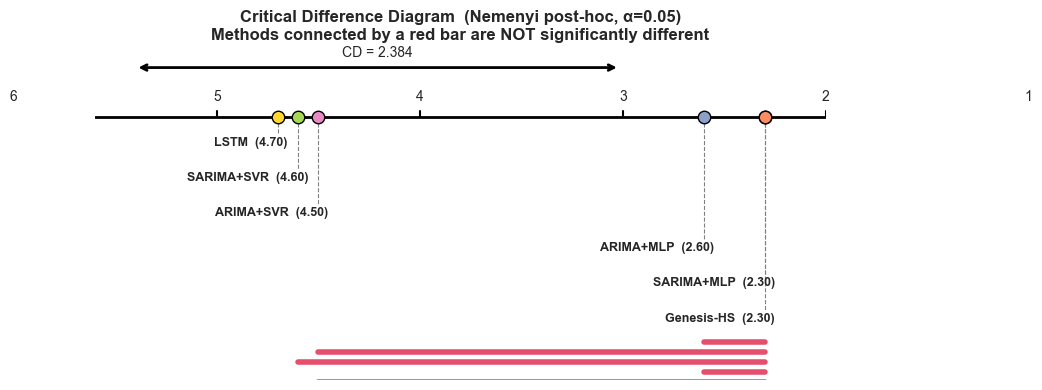

In [13]:
# ── (1) Critical Difference (CD) Diagram ────────────────────────────────────
# Standard companion to the Nemenyi test (Demšar 2006).
# Connects methods whose rank difference < CD with a thick bar → not sig. different.
#
# q_{0.05} for k=6 from Demšar 2006 Table 5: 2.850
# CD = q * sqrt(k*(k+1) / (6*N))

q_alpha    = 2.850   # Nemenyi critical value for k=6, alpha=0.05
k_methods  = len(METHOD_ORDER)
N_datasets = len(datasets)
cd_value   = q_alpha * np.sqrt(k_methods * (k_methods + 1) / (6 * N_datasets))
print(f"Critical Difference (α=0.05, k={k_methods}, N={N_datasets}): CD = {cd_value:.4f}")

sorted_ranks = mean_ranks.sort_values()
methods_s    = sorted_ranks.index.tolist()
ranks_s      = sorted_ranks.values

fig, ax = plt.subplots(figsize=(11, 4))

lo, hi = min(ranks_s) - 0.3, max(ranks_s) + 0.3
ax.set_xlim(lo, hi + 0.6)
ax.set_ylim(-1.5, len(methods_s) + 1.8)
ax.invert_xaxis()   # rank 1 (best) on the right

# Axis line
ax.plot([lo, hi + 0.6], [len(methods_s), len(methods_s)], color='black', linewidth=2)

# Tick marks & labels
for r in np.arange(1, len(METHOD_ORDER) + 1):
    ax.plot([r, r], [len(methods_s), len(methods_s) + 0.15], color='black', linewidth=1.5)
    ax.text(r, len(methods_s) + 0.35, str(r), ha='center', va='bottom', fontsize=10)

# Vertical connectors + method labels
palette_cd = sns.color_palette("Set2", n_colors=len(methods_s))
for i, (m, r) in enumerate(zip(methods_s, ranks_s)):
    y_pos = i
    ax.plot([r, r], [len(methods_s), y_pos + 0.5],
            color='gray', linewidth=0.8, linestyle='--')
    ax.plot(r, len(methods_s), 'o',
            color=palette_cd[i], markersize=9, zorder=5,
            markeredgecolor='black', markeredgewidth=1)
    ax.text(r - 0.05, y_pos + 0.25,
            f'{m}  ({r:.2f})',
            ha='right', va='center', fontsize=9, fontweight='bold')

# CD annotation (top-left)
cd_x1 = hi + 0.4
cd_x2 = cd_x1 - cd_value
ax.annotate('',
    xy=(cd_x2, len(methods_s) + 1.4),
    xytext=(cd_x1, len(methods_s) + 1.4),
    arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text((cd_x1 + cd_x2) / 2, len(methods_s) + 1.62,
        f'CD = {cd_value:.3f}',
        ha='center', va='bottom', fontsize=10)

# Non-significant groups (|rank_i - rank_j| < CD)
y_bars = []
used_y = []
for i in range(len(methods_s)):
    for j in range(i + 1, len(methods_s)):
        if abs(ranks_s[i] - ranks_s[j]) < cd_value:
            y_try = -0.15
            while y_try in used_y:
                y_try -= 0.28
            used_y.append(y_try)
            ax.plot([ranks_s[i], ranks_s[j]], [y_try, y_try],
                    color='crimson', linewidth=4, alpha=0.75, solid_capstyle='round')

ax.axis('off')
ax.set_title(
    f'Critical Difference Diagram  (Nemenyi post-hoc, α=0.05)\n'
    f'Methods connected by a red bar are NOT significantly different',
    fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

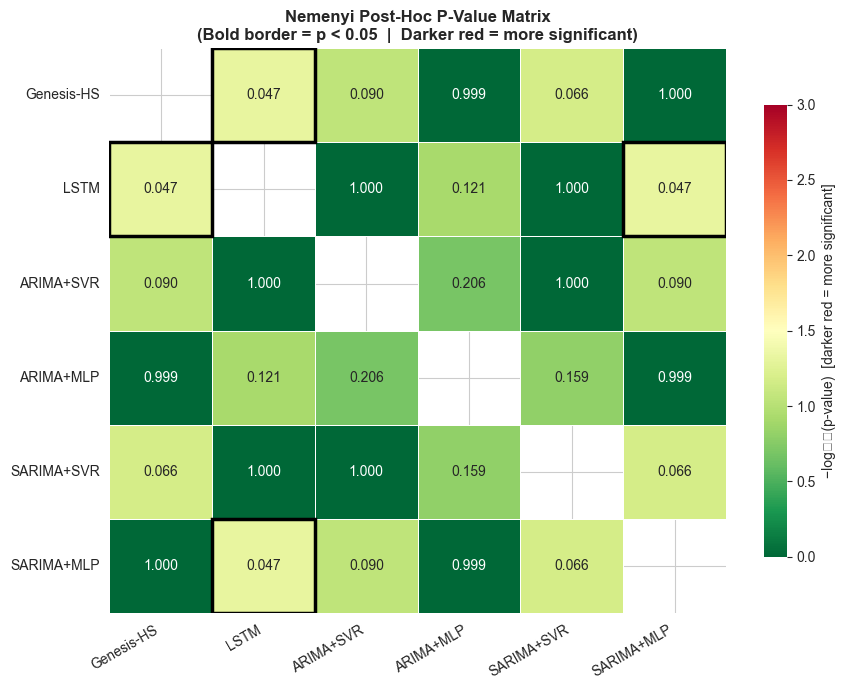

Pairs with bold border are statistically significantly different (p < 0.05)


In [14]:
# ── (2) Nemenyi P-Value Heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

mask = np.eye(len(METHOD_ORDER), dtype=bool)

# Annotate with actual p-values
annot_mat = nemenyi_p.copy().astype(str)
for i in range(len(METHOD_ORDER)):
    for j in range(len(METHOD_ORDER)):
        if i == j:
            annot_mat.iloc[i, j] = '—'
        else:
            annot_mat.iloc[i, j] = f"{nemenyi_p.iloc[i, j]:.3f}"

# Color by -log10(p) so significant cells stand out
log_p_arr = nemenyi_p.to_numpy(dtype=float).copy()
np.fill_diagonal(log_p_arr, np.nan)
log_p_clipped = np.where(np.isnan(log_p_arr), np.nan,
                         np.clip(log_p_arr, 1e-10, None))
log_p_vals = -np.log10(log_p_clipped, where=~np.isnan(log_p_clipped),
                       out=np.full_like(log_p_clipped, np.nan))
log_p_vals_df = pd.DataFrame(log_p_vals, index=METHOD_ORDER, columns=METHOD_ORDER)

sns.heatmap(
    log_p_vals_df,
    annot=annot_mat,
    fmt='',
    cmap='RdYlGn_r',
    mask=mask,
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=3,
    cbar_kws={'label': '−log₁₀(p-value)  [darker red = more significant]', 'shrink': 0.8},
)

# Bold border for significant cells (p < 0.05)
for i, m1 in enumerate(METHOD_ORDER):
    for j, m2 in enumerate(METHOD_ORDER):
        if i != j and nemenyi_p.loc[m1, m2] < 0.05:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1, fill=False, edgecolor='black', lw=2.5))

ax.set_title(
    'Nemenyi Post-Hoc P-Value Matrix\n(Bold border = p < 0.05  |  Darker red = more significant)',
    fontsize=12, fontweight='bold')
ax.set_xticklabels(METHOD_ORDER, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(METHOD_ORDER, rotation=0,  fontsize=10)
plt.tight_layout()
plt.show()
print("Pairs with bold border are statistically significantly different (p < 0.05)")

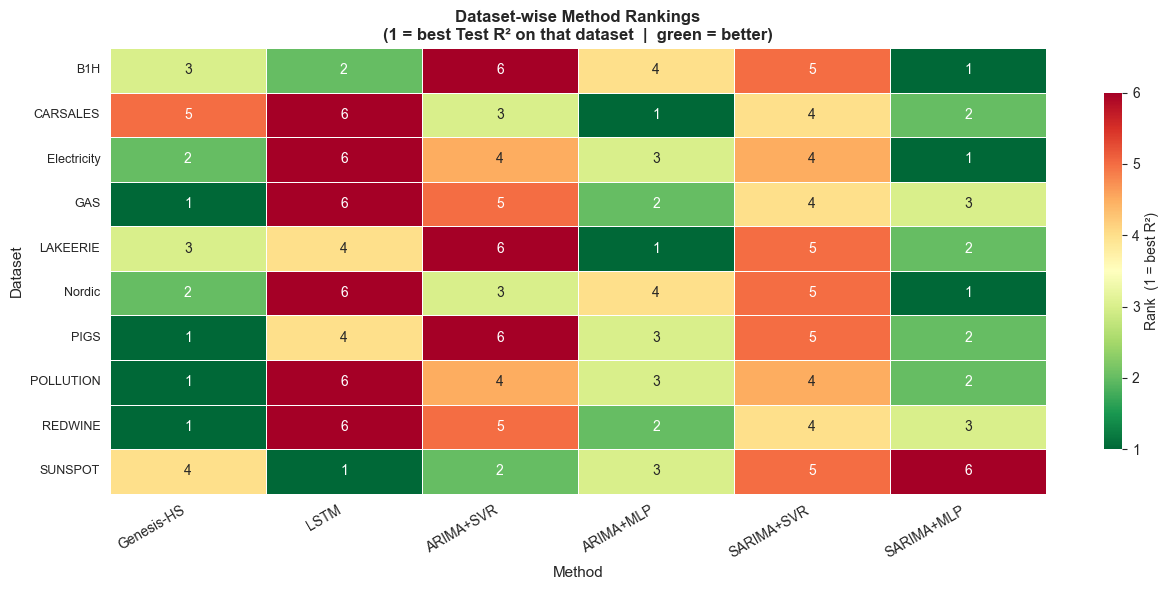

In [15]:
# ── (3) Dataset-wise Rank Heatmap ────────────────────────────────────────────
rank_display = rank_matrix[METHOD_ORDER]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    rank_display,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn_r',
    vmin=1,
    vmax=len(METHOD_ORDER),
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Rank  (1 = best R²)', 'shrink': 0.8},
)
ax.set_title(
    'Dataset-wise Method Rankings\n(1 = best Test R² on that dataset  |  green = better)',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Method', fontsize=11)
ax.set_ylabel('Dataset', fontsize=11)
ax.set_xticklabels(METHOD_ORDER, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(datasets, rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

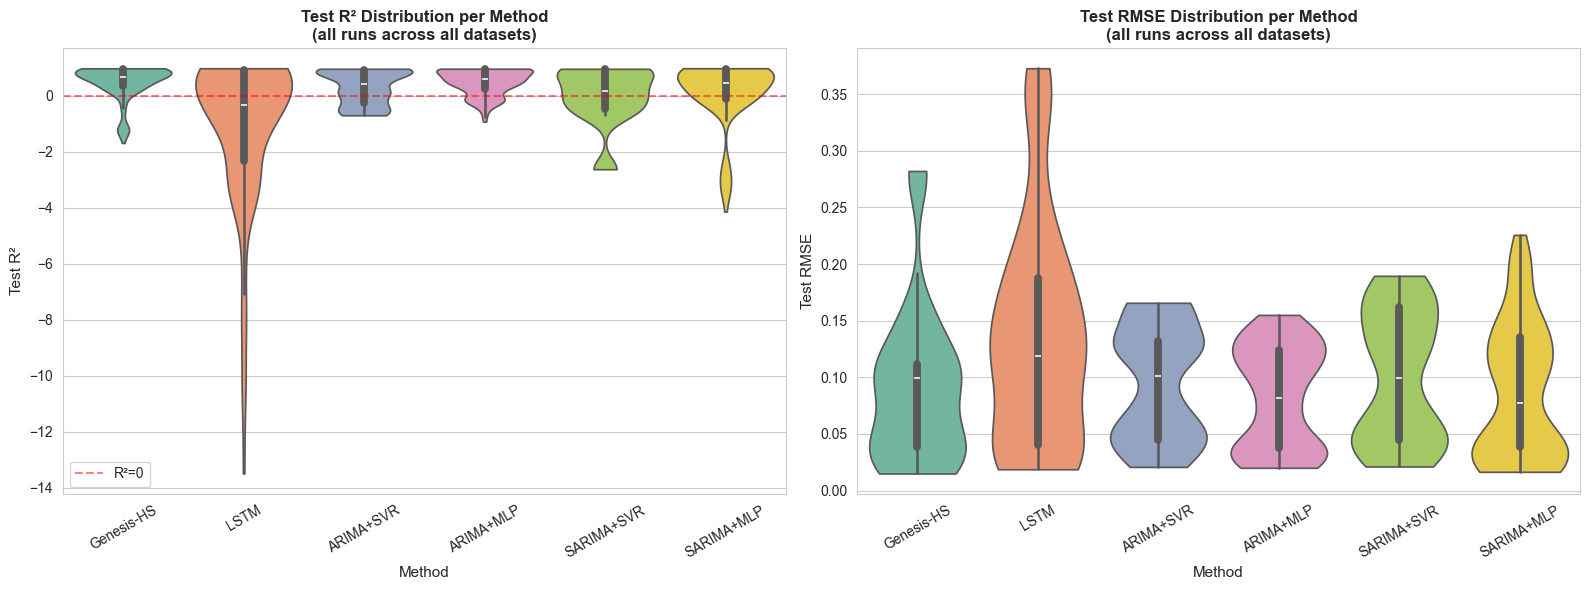

In [16]:
# ── (4) Violin Plots — Test R² and RMSE ─────────────────────────────────────
violin_rows      = []
violin_rmse_rows = []

# Genesis-HS
for _, row in ge_results.iterrows():
    violin_rows.append(      {'Method': 'Genesis-HS', 'value': row['r2_test']})
    violin_rmse_rows.append( {'Method': 'Genesis-HS', 'value': row['rmse_test']})

# LSTM
for _, row in lstm_results.iterrows():
    violin_rows.append(      {'Method': 'LSTM', 'value': row['r2_test']})
    violin_rmse_rows.append( {'Method': 'LSTM', 'value': row['rmse_test']})

# Hybrid
name_map = {'ARIMA_SVR':'ARIMA+SVR','ARIMA_MLP':'ARIMA+MLP',
            'SARIMA_SVR':'SARIMA+SVR','SARIMA_MLP':'SARIMA+MLP'}
for _, row in hybrid_results.iterrows():
    display = name_map[row['method']]
    violin_rows.append(      {'Method': display, 'value': row['r2_test']})
    violin_rmse_rows.append( {'Method': display, 'value': row['rmse_test']})

violin_df      = pd.DataFrame(violin_rows)
violin_rmse_df = pd.DataFrame(violin_rmse_rows)
palette        = sns.color_palette("Set2", n_colors=6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=violin_df, x='Method', y='value', order=METHOD_ORDER,
               palette=palette, ax=axes[0], inner='box', cut=0)
axes[0].set_title('Test R² Distribution per Method\n(all runs across all datasets)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Method', fontsize=11)
axes[0].set_ylabel('Test R²', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='R²=0')
axes[0].legend(fontsize=10)

sns.violinplot(data=violin_rmse_df, x='Method', y='value', order=METHOD_ORDER,
               palette=palette, ax=axes[1], inner='box', cut=0)
axes[1].set_title('Test RMSE Distribution per Method\n(all runs across all datasets)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Method', fontsize=11)
axes[1].set_ylabel('Test RMSE', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

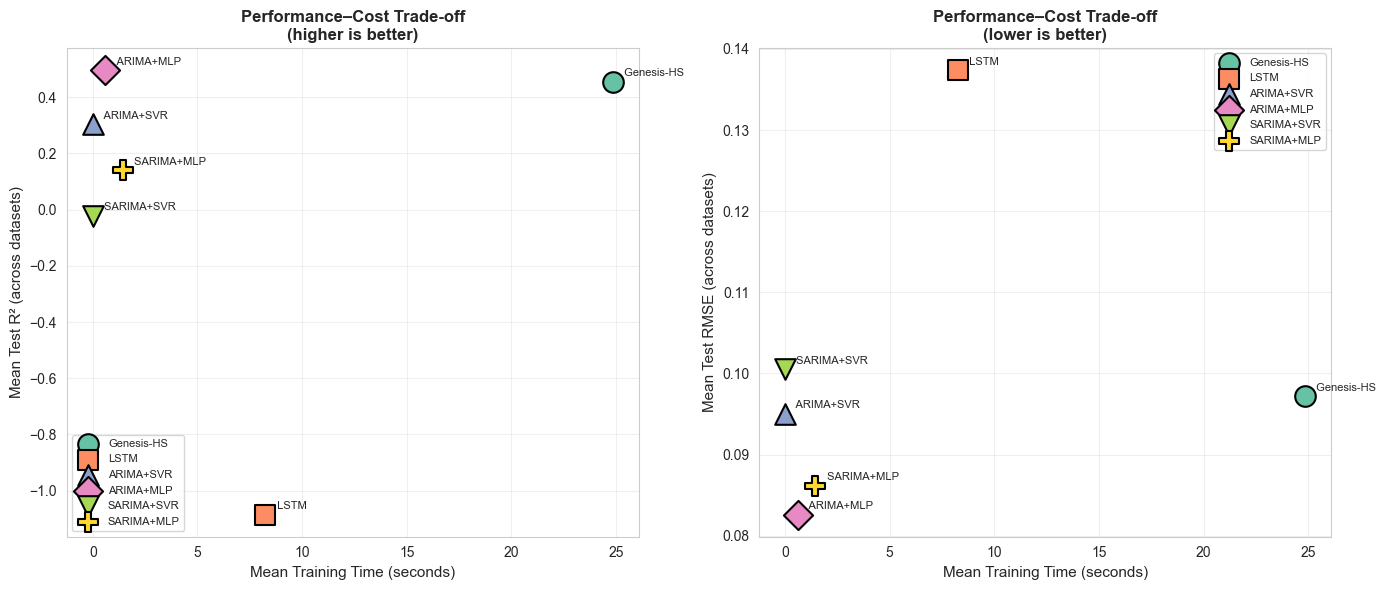

Method        | Mean Time (s) | Mean R²   | Mean RMSE
-------------------------------------------------------
Genesis-HS    |        24.846 |    0.4545 | 0.0972
LSTM          |         8.241 |   -1.0848 | 0.1374
ARIMA+SVR     |         0.001 |    0.3044 | 0.0950
ARIMA+MLP     |         0.599 |    0.4965 | 0.0826
SARIMA+SVR    |         0.001 |   -0.0214 | 0.1005
SARIMA+MLP    |         1.452 |    0.1404 | 0.0862


In [17]:
# ── (5) Performance–Cost Scatter (Pareto view) ───────────────────────────────
mean_r2   = perf_matrix_r2.mean()
mean_rmse = perf_matrix_rmse.mean()
mean_time = perf_matrix_time.mean()
palette   = sns.color_palette("Set2", n_colors=6)
markers   = ['o', 's', '^', 'D', 'v', 'P']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_vals, y_label, better) in zip(axes, [
    (mean_r2,   'Mean Test R² (across datasets)',   'higher is better'),
    (mean_rmse, 'Mean Test RMSE (across datasets)', 'lower is better'),
]):
    for i, m in enumerate(METHOD_ORDER):
        ax.scatter(mean_time[m], y_vals[m],
                   s=220, color=palette[i], marker=markers[i],
                   edgecolors='black', linewidths=1.5, zorder=5, label=m)
        ax.annotate(f' {m}', (mean_time[m], y_vals[m]),
                    fontsize=8, xytext=(6, 4), textcoords='offset points')
    ax.set_xlabel('Mean Training Time (seconds)', fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(f'Performance–Cost Trade-off\n({better})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Method        | Mean Time (s) | Mean R²   | Mean RMSE")
print("-" * 55)
for m in METHOD_ORDER:
    print(f"{m:13s} | {mean_time[m]:13.3f} | {mean_r2[m]:9.4f} | {mean_rmse[m]:.4f}")

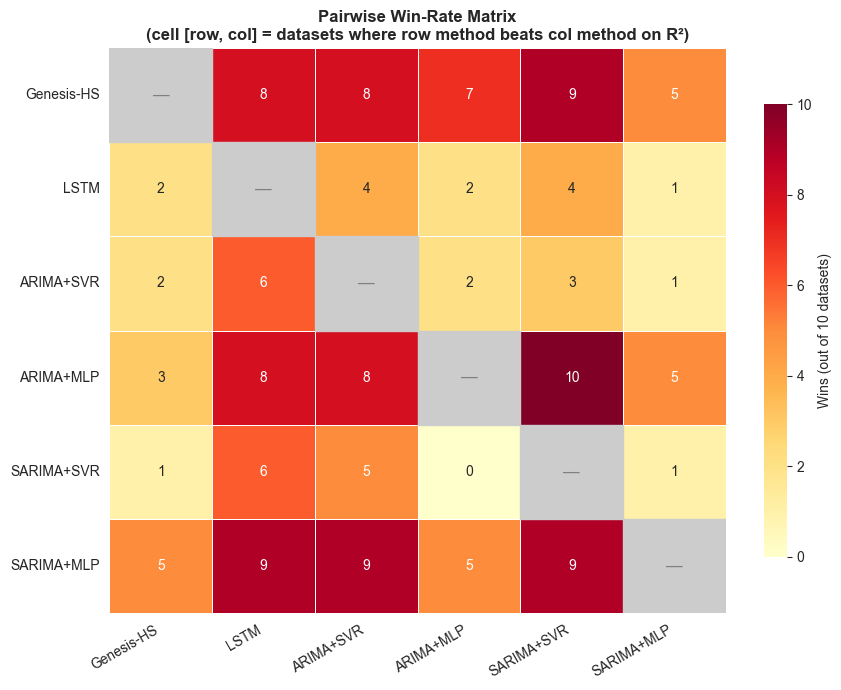

In [18]:
# ── (6) Pairwise Win-Rate Matrix Heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

diag_mask = np.eye(len(METHOD_ORDER), dtype=bool)
annot_win = win_df.astype(str)
for i in range(len(METHOD_ORDER)):
    annot_win.iloc[i, i] = '—'

sns.heatmap(
    win_df.where(~diag_mask),
    annot=annot_win,
    fmt='',
    cmap='YlOrRd',
    mask=diag_mask,
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=len(datasets),
    cbar_kws={'label': f'Wins (out of {len(datasets)} datasets)', 'shrink': 0.8},
)
# Gray diagonal
for i in range(len(METHOD_ORDER)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#cccccc'))
    ax.text(i + 0.5, i + 0.5, '—', ha='center', va='center',
            fontsize=12, color='gray')

ax.set_title(
    'Pairwise Win-Rate Matrix\n(cell [row, col] = datasets where row method beats col method on R²)',
    fontsize=12, fontweight='bold')
ax.set_xticklabels(METHOD_ORDER, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(METHOD_ORDER, rotation=0,  fontsize=10)
plt.tight_layout()
plt.show()

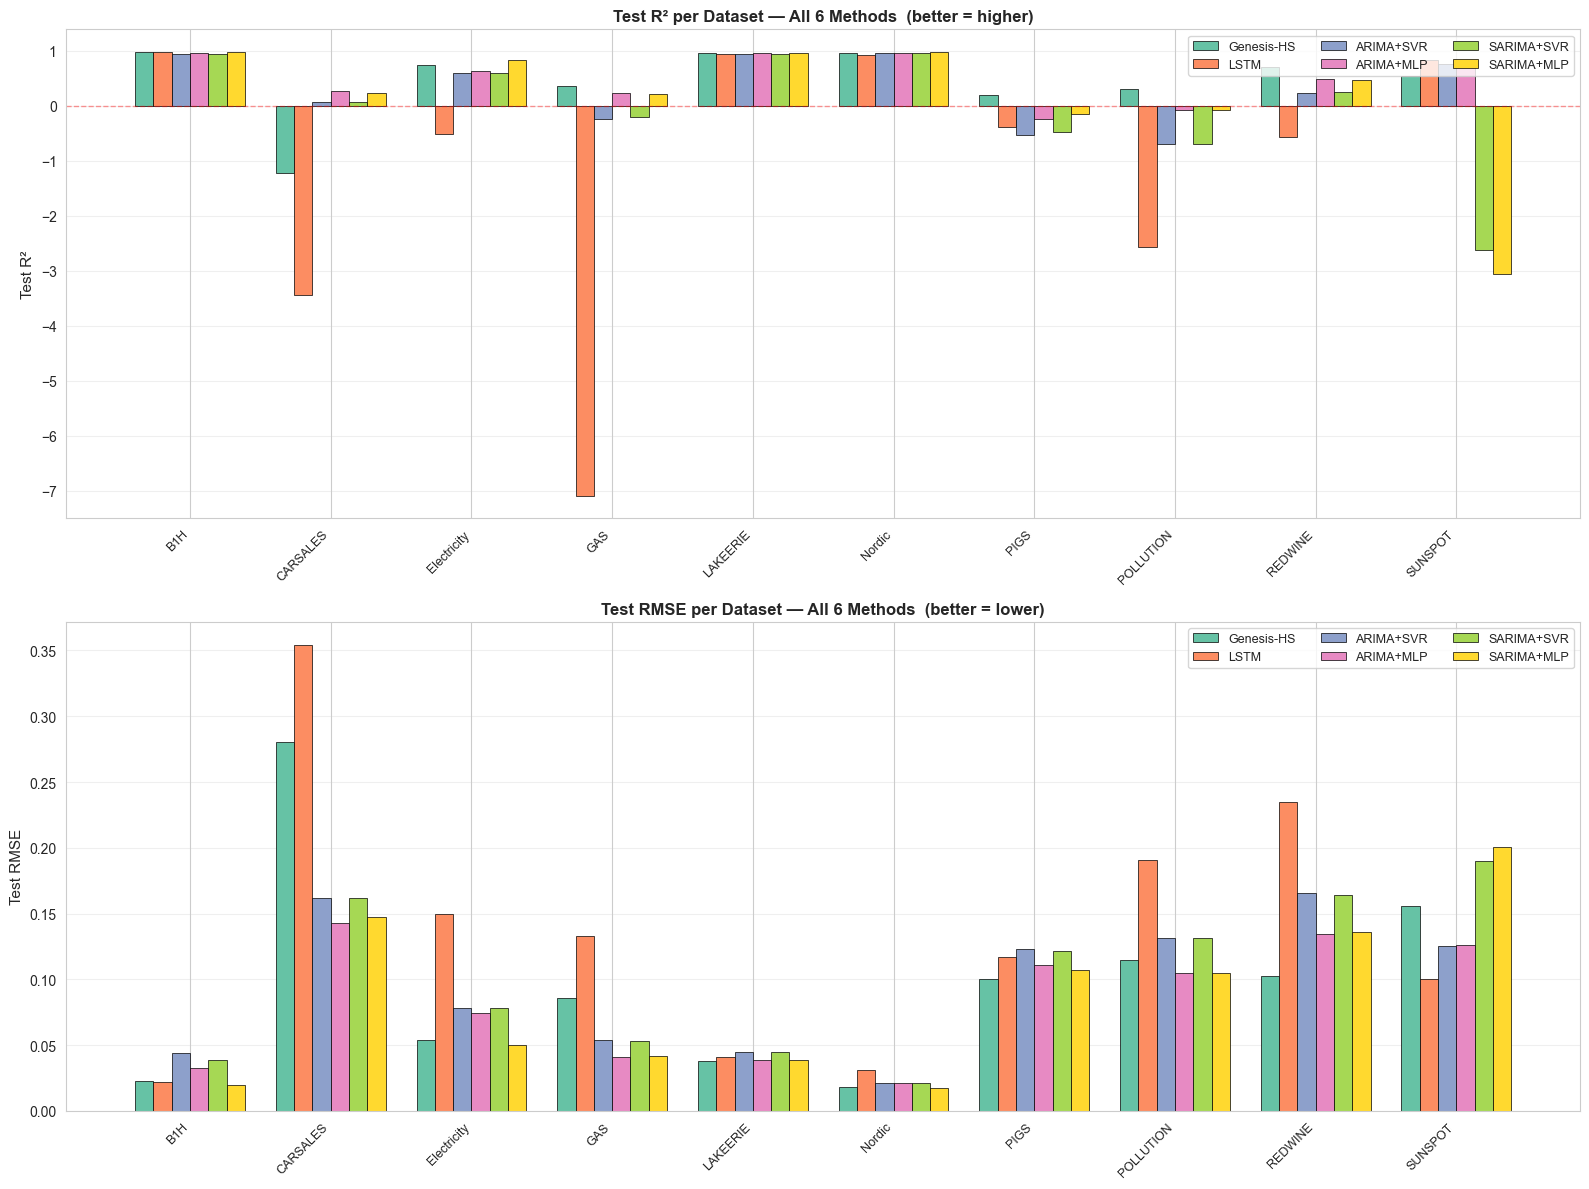

In [19]:
# ── (7) Grouped Bar Charts — R² and RMSE per Dataset ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
x         = np.arange(len(datasets))
width     = 0.13
palette   = sns.color_palette("Set2", n_colors=6)

for ax, (metric, label, better) in zip(axes, [
    ('r2_test',   'Test R²',   'higher'),
    ('rmse_test', 'Test RMSE', 'lower'),
]):
    for i, (m, agg) in enumerate(all_agg.items()):
        vals   = [agg.loc[d, metric] for d in datasets]
        offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
        ax.bar(x + offset, vals, width, label=m,
               color=palette[i], edgecolor='black', linewidth=0.5)

    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label} per Dataset — All 6 Methods  (better = {better})',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9, ncol=3, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    if metric == 'r2_test':
        ax.axhline(0, color='red', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.show()

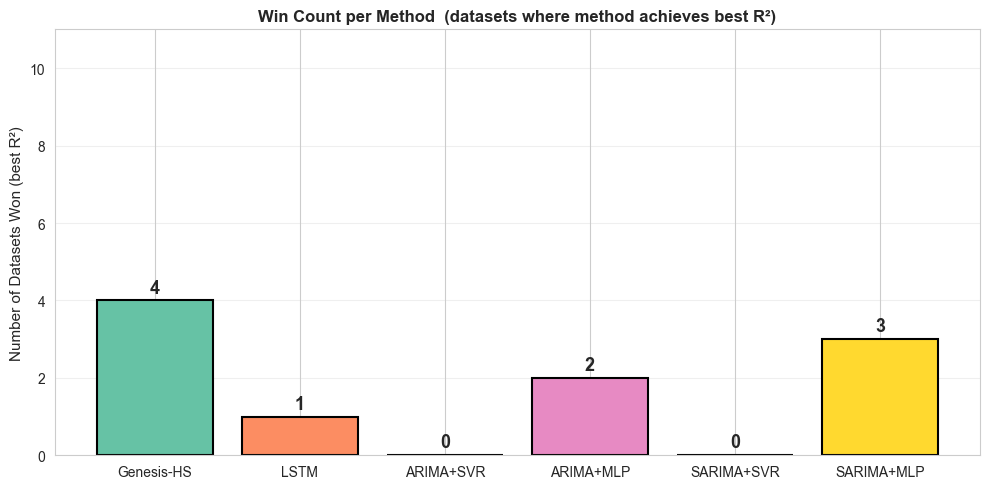

Win counts: {'Genesis-HS': 4, 'LSTM': 1, 'ARIMA+SVR': 0, 'ARIMA+MLP': 2, 'SARIMA+SVR': 0, 'SARIMA+MLP': 3}


In [20]:
# ── Win-count bar chart (how many datasets each method wins overall) ──────────
win_counts = {m: int((perf_matrix_r2[m] == perf_matrix_r2.max(axis=1)).sum())
              for m in METHOD_ORDER}

palette  = sns.color_palette("Set2", n_colors=6)
fig, ax  = plt.subplots(figsize=(10, 5))
bars     = ax.bar(METHOD_ORDER, win_counts.values(),
                  color=palette, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Datasets Won (best R²)', fontsize=11)
ax.set_title('Win Count per Method  (datasets where method achieves best R²)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, len(datasets) + 1)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, win_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Win counts:", win_counts)

## 6. Computational Efficiency

COMPUTATIONAL COST — ALL 6 METHODS
Method          |   Mean (s) | Median (s) |      Std |     Min |     Max
----------------------------------------------------------------------
Genesis-HS      |     24.846 |     24.444 |    1.439 |  23.111 |  27.363
LSTM            |      8.241 |      3.114 |   10.954 |   0.476 |  32.871
ARIMA+SVR       |      0.001 |      0.001 |    0.000 |   0.001 |   0.001
ARIMA+MLP       |      0.599 |      0.470 |    0.425 |   0.140 |   1.458
SARIMA+SVR      |      0.001 |      0.001 |    0.000 |   0.001 |   0.001
SARIMA+MLP      |      1.452 |      0.271 |    2.362 |   0.129 |   7.218


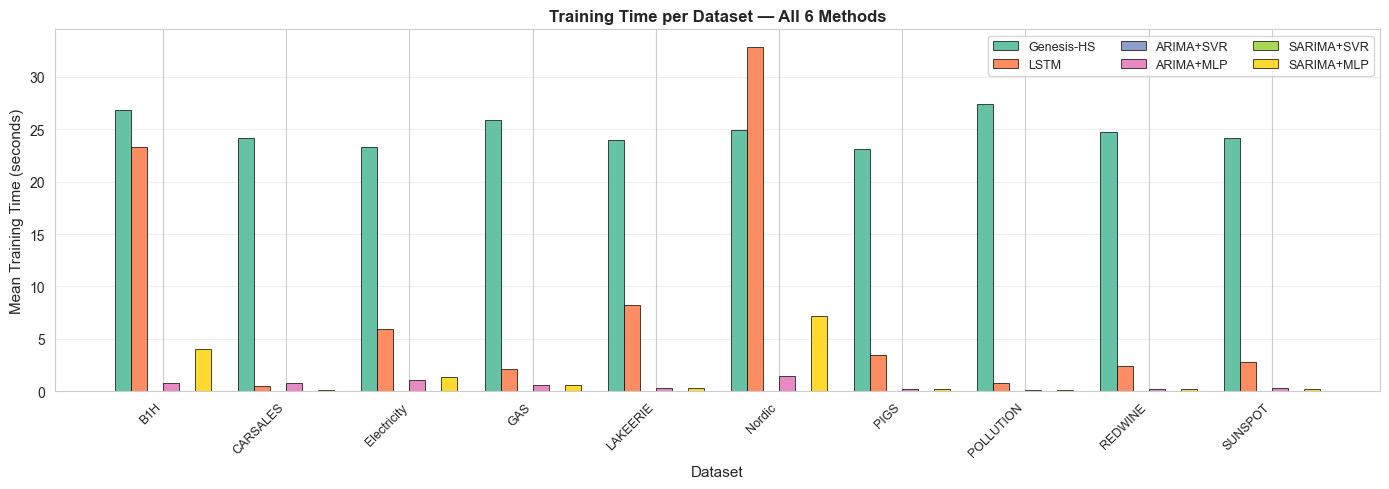

In [21]:
print("COMPUTATIONAL COST — ALL 6 METHODS")
print("=" * 70)
print(f"{'Method':15s} | {'Mean (s)':>10} | {'Median (s)':>10} | {'Std':>8} | {'Min':>7} | {'Max':>7}")
print("-" * 70)
for m in METHOD_ORDER:
    t = perf_matrix_time[m]
    print(f"{m:15s} | {t.mean():10.3f} | {t.median():10.3f} | {t.std():8.3f} | {t.min():7.3f} | {t.max():7.3f}")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(datasets))
width = 0.13
palette = sns.color_palette("Set2", n_colors=6)
for i, (m, agg) in enumerate(all_agg.items()):
    vals   = [agg.loc[d, 'total_time'] for d in datasets]
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=m,
           color=palette[i], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Dataset', fontsize=11)
ax.set_ylabel('Mean Training Time (seconds)', fontsize=11)
ax.set_title('Training Time per Dataset — All 6 Methods', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9, ncol=3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Statistical Conclusions and Summary Report

In [22]:
# ── Final summary report ─────────────────────────────────────────────────────
mean_r2_all = {m: round(perf_matrix_r2[m].mean(), 4)   for m in METHOD_ORDER}
mean_rm_all = {m: round(perf_matrix_rmse[m].mean(), 4) for m in METHOD_ORDER}
ge_wins_vs  = {m: int((perf_matrix_r2['Genesis-HS'] > perf_matrix_r2[m]).sum())
               for m in METHOD_ORDER if m != 'Genesis-HS'}

best_method = mean_ranks.idxmin()

print("=" * 80)
print("COMPREHENSIVE STATISTICAL ANALYSIS REPORT")
print("Genesis-HS vs LSTM + 4 Hybrid Methods  (10 datasets, 15 runs each)")
print("=" * 80)

print("\n1. FRIEDMAN TEST (omnibus)")
print(f"   Chi² = {f_stat:.4f},  p = {f_pval:.6f}")
print(f"   {'SIGNIFICANT' if f_pval < 0.05 else 'NOT SIGNIFICANT'} at α = 0.05")

print("\n2. MEAN RANKS  (Demšar 2006,  lower = better)")
for m, r in mean_ranks.items():
    print(f"   {m:15s}: {r:.4f}{'  ← top-ranked' if m == best_method else ''}")

print(f"\n3. NEMENYI POST-HOC  (CD = {cd_value:.4f} at α = 0.05)")
for m in [x for x in METHOD_ORDER if x != 'Genesis-HS']:
    p   = nemenyi_p.loc['Genesis-HS', m]
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"   Genesis-HS  vs  {m:15s} : p = {p:.4f}  ({sig})")

print("\n4. SUPPLEMENTARY WILCOXON  (Genesis-HS vs LSTM)")
print(f"   W = {w_stat:.4f},  p = {w_pval:.6f}  "
      f"({'Significant' if w_pval < 0.05 else 'Not significant'})")
print(f"   Cohen's d = {cohens_d:.4f} ({effect} effect size)")

print("\n5. ABSOLUTE PERFORMANCE")
print(f"   {'Method':15s} | {'Mean R²':>9} | {'Mean RMSE':>10}")
print(f"   {'-'*40}")
for m in METHOD_ORDER:
    print(f"   {m:15s} | {mean_r2_all[m]:9.4f} | {mean_rm_all[m]:10.4f}")

print("\n6. GENESIS-HS WIN COUNT vs EACH COMPETITOR  (Test R²)")
for m, w in ge_wins_vs.items():
    print(f"   Genesis-HS vs {m:15s}: {w}/{len(datasets)} datasets ({w/len(datasets)*100:.0f}%)")

print("\n7. COMPUTATIONAL COST  (mean training time)")
for m in METHOD_ORDER:
    print(f"   {m:15s}: {perf_matrix_time[m].mean():.3f}s")

print()
print("=" * 80)
print("REVIEWER RESPONSE SUMMARY")
print("=" * 80)
print(
    "Request 1 -- Quantitative evaluation with statistical metrics:\n"
    f"  Friedman test: chi2={f_stat:.4f}, p={f_pval:.6f}\n"
    f"  {'Significant differences exist.' if f_pval < 0.05 else 'No significant differences.'}\n"
    f"  Mean ranks: {', '.join(f'{m}={r:.2f}' for m, r in mean_ranks.items())}\n"
    "\n"
    "Request 2 -- Nemenyi post-hoc for Genesis-HS vs top methods:\n"
    f"  Genesis-HS vs ARIMA+SVR  : p = {nemenyi_p.loc['Genesis-HS','ARIMA+SVR']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','ARIMA+SVR'] < 0.05 else 'not significant'})\n"
    f"  Genesis-HS vs SARIMA+SVR : p = {nemenyi_p.loc['Genesis-HS','SARIMA+SVR']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','SARIMA+SVR'] < 0.05 else 'not significant'})\n"
    f"  Genesis-HS vs ARIMA+MLP  : p = {nemenyi_p.loc['Genesis-HS','ARIMA+MLP']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','ARIMA+MLP'] < 0.05 else 'not significant'})\n"
    f"  Genesis-HS vs SARIMA+MLP : p = {nemenyi_p.loc['Genesis-HS','SARIMA+MLP']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','SARIMA+MLP'] < 0.05 else 'not significant'})\n"
    f"  Genesis-HS vs LSTM       : p = {nemenyi_p.loc['Genesis-HS','LSTM']:.4f}  "
    f"({'SIGNIFICANT' if nemenyi_p.loc['Genesis-HS','LSTM'] < 0.05 else 'not significant'})"
)

summary_txt = f"""
STATISTICAL ANALYSIS SUMMARY: Genesis-HS vs 5 Methods
======================================================
Methods compared : {len(METHOD_ORDER)}
Datasets analyzed: {len(datasets)}
Runs per config  : 15

FRIEDMAN TEST:
  Chi² = {f_stat:.4f},  p = {f_pval:.6f}
  Significant: {'Yes' if f_pval < 0.05 else 'No'}

MEAN RANKS:
{chr(10).join(f'  {m}: {r:.4f}' for m,r in mean_ranks.items())}

NEMENYI POST-HOC (Genesis-HS vs each):
{chr(10).join(f'  vs {m}: p={nemenyi_p.loc["Genesis-HS",m]:.4f}' for m in METHOD_ORDER if m!='Genesis-HS')}

WILCOXON (GE vs LSTM, supplementary):
  W={w_stat:.4f}, p={w_pval:.6f}, Cohen_d={cohens_d:.4f} ({effect})
"""
with open('results/statistical_analysis_summary.txt', 'w') as fh:
    fh.write(summary_txt)
print("Saved → results/statistical_analysis_summary.txt")

COMPREHENSIVE STATISTICAL ANALYSIS REPORT
Genesis-HS vs LSTM + 4 Hybrid Methods  (10 datasets, 15 runs each)

1. FRIEDMAN TEST (omnibus)
   Chi² = 21.0920,  p = 0.000778
   SIGNIFICANT at α = 0.05

2. MEAN RANKS  (Demšar 2006,  lower = better)
   Genesis-HS     : 2.3000  ← top-ranked
   SARIMA+MLP     : 2.3000
   ARIMA+MLP      : 2.6000
   ARIMA+SVR      : 4.5000
   SARIMA+SVR     : 4.6000
   LSTM           : 4.7000

3. NEMENYI POST-HOC  (CD = 2.3845 at α = 0.05)
   Genesis-HS  vs  LSTM            : p = 0.0474  (SIGNIFICANT)
   Genesis-HS  vs  ARIMA+SVR       : p = 0.0902  (not significant)
   Genesis-HS  vs  ARIMA+MLP       : p = 0.9992  (not significant)
   Genesis-HS  vs  SARIMA+SVR      : p = 0.0660  (not significant)
   Genesis-HS  vs  SARIMA+MLP      : p = 1.0000  (not significant)

4. SUPPLEMENTARY WILCOXON  (Genesis-HS vs LSTM)
   W = 5.0000,  p = 0.019531  (Significant)
   Cohen's d = 0.6974 (medium effect size)

5. ABSOLUTE PERFORMANCE
   Method          |   Mean R² |  Mean R